In [ ]:
from utils import load_data

train_path = "train.csv"
val_path = "validation.csv"

train_data = load_data(train_path)
val_data = load_data(val_path)

torch.Size([32, 3, 224, 224])
torch.Size([32])
tensor(0)


[ WARN:0@4.818] global loadsave.cpp:1089 imwrite_ Unsupported depth image for selected encoder is fallbacked to CV_8U.


torch.Size([32, 3, 224, 224])
torch.Size([32])
tensor(5)


In [6]:
import torch
import torch.nn as nn
import timm

model = timm.create_model('deit3_small_patch16_224', pretrained=True)

# Replace classification head
model.head = nn.Linear(model.head.in_features, 10)

In [7]:
import torch.optim as optim
import params

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=params.lr)

In [8]:
outfile = open("results.txt", 'a')
outfile.write("----------------------------\n")
outfile.write("Training for task 2.1\n")
outfile.write("---------------------\n")

22

In [9]:
from sklearn.metrics import roc_auc_score
import numpy as np
from sklearn.preprocessing import label_binarize
import time
from params import num_epochs

best_auc = 0
best_model_state = None

losses = []
auc_vals = []

for epoch in range(num_epochs):
    start = time.time()
    model.train()
    train_loss = 0

    outfile.write(f"Running epoch: {epoch+1}\n")

    # ---- Training ----
    for images, labels in train_data:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_data)

    # ---- Validation ----
    model.eval()
    all_labels = []
    all_probs = []

    outfile.write("  Evaluating...\n")

    with torch.no_grad():
        for images, labels in val_data:
            images = images.to(device)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)

            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.numpy())

    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)

    y_true = label_binarize(all_labels, classes=list(range(10)))

    auc = roc_auc_score(y_true, all_probs, average='macro', multi_class='ovr')
    losses.append(train_loss)
    auc_vals.append(auc)

    outfile.write(f"Epoch {epoch+1} done, Val AUC: {auc:.4f}\n")
    outfile.write(f"Time taken: {time.time() - start:.2f}s\n")

    # ---- Save best model ----
    if auc > best_auc:
        best_auc = auc
        best_model_state = model.state_dict()

In [10]:
outfile.close()

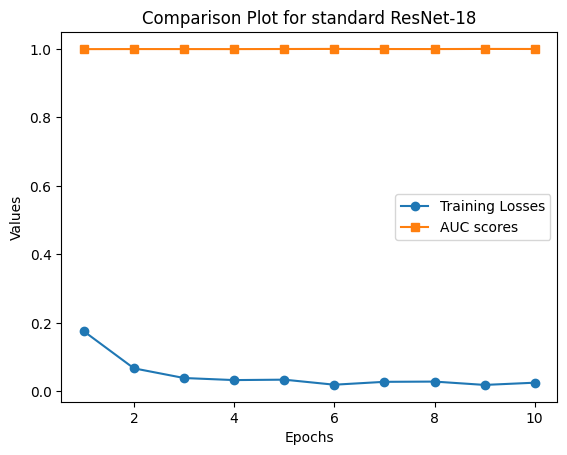

In [11]:
import matplotlib.pyplot as plt

x = list(range(1, 11))

plt.plot(x, losses, marker='o', label='Training Losses')
plt.plot(x, auc_vals, marker='s', label='AUC scores')

plt.xlabel("Epochs")
plt.ylabel("Values")
plt.title("Comparison Plot for standard ResNet-18")
plt.legend()
plt.savefig("Train_plot21.png")
plt.show()

In [12]:
torch.save(best_model_state, "best_model21.pth")

print("Training complete. Best AUC:", best_auc)

Training complete. Best AUC: 0.9997719992630385


In [13]:
with open("results.txt", "a") as f:
    f.write("\n------------------------------\n")
    f.write("Train results for 2.1\n")
    f.write("------------------------------\n")
    f.write("Losses:\n")
    for ls in losses:
        f.write(f"{ls}\n")
    f.write("AUC values:\n")
    for auc in auc_vals:
        f.write(f"{auc}\n")